In [2]:
# imports
import pandas as pd
import optuna # pip install optuna
import matplotlib.pyplot as plt
import numpy as np

#froms
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from sklearn.model_selection import ParameterGrid


In [4]:
# globales
df = pd.read_csv("../../data/dataset_training.csv", encoding="ISO-8859-1", low_memory=False)
dfPredicReal = pd.read_csv("../../data/dataset_prediction.csv", encoding="ISO-8859-1", low_memory=False)
print(f'\n DF limpio:')
print(df.info())
#scaling_factor = 1000 



 DF limpio:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 415181 entries, 0 to 415180
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Unnamed: 0   415181 non-null  int64  
 1   InvoiceNo    415181 non-null  object 
 2   StockCode    415181 non-null  object 
 3   Description  415181 non-null  object 
 4   Quantity     415181 non-null  int64  
 5   InvoiceDate  415181 non-null  object 
 6   UnitPrice    415181 non-null  float64
 7   CustomerID   415181 non-null  float64
 8   Country      415181 non-null  object 
 9   TotalSales   415181 non-null  float64
 10  Year         415181 non-null  int64  
 11  Month        415181 non-null  int64  
 12  Day          415181 non-null  int64  
 13  DayOfWeek    415181 non-null  int64  
 14  Quarter      415181 non-null  int64  
 15  Season       415181 non-null  object 
dtypes: float64(3), int64(7), object(6)
memory usage: 50.7+ MB
None


In [6]:
# paso a datetime por si acaso
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
# se necesitan dos columnas 'ds' e 'y', ds son las fechas, 'y' los valores que se quiere predecir
dfPreparacion= df.groupby(df['InvoiceDate'].dt.date)['TotalSales'].sum().reset_index()
dfPreparacion.columns = ['ds', 'y']
dfPreparacion['ds'] = pd.to_datetime(dfPreparacion['ds'])
print(f'\n DF de preparacion:')
print(dfPreparacion.info())
print(dfPreparacion.head())


 DF de preparacion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      277 non-null    datetime64[ns]
 1   y       277 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.5 KB
None
          ds         y
0 2010-12-01  31033.52
1 2010-12-02  26161.82
2 2010-12-03  22908.14
3 2010-12-05  21972.42
4 2010-12-06  36549.31


In [8]:
# para el calculo de mae
dfPredicReal['InvoiceDate'] = pd.to_datetime(dfPredicReal['InvoiceDate'])
yReal=dfPredicReal.groupby(dfPredicReal['InvoiceDate'].dt.date)['TotalSales'].sum().reset_index()
yReal['InvoiceDate'] = pd.to_datetime(yReal['InvoiceDate'])

#Añadimos fechas que faltan
yReal = yReal.set_index('InvoiceDate').resample('D').mean().fillna(0)
yReal = yReal.reset_index()

print(yReal.info())
print(yReal.head())

# dejamos solo el valor
yRealValues= yReal['TotalSales'].values
print(f"\n Sin fecha:")
print(yRealValues)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceDate  32 non-null     datetime64[ns]
 1   TotalSales   32 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 644.0 bytes
None
  InvoiceDate  TotalSales
0  2011-11-08    39681.92
1  2011-11-09    30888.52
2  2011-11-10    37581.64
3  2011-11-11    38162.18
4  2011-11-12        0.00

 Sin fecha:
[39681.92 30888.52 37581.64 38162.18     0.   25752.48 32750.2  32119.82
 42345.4  38791.76 27401.78     0.   27056.37 29540.22 36823.67 37230.13
 36796.56 27982.22     0.   16633.18 33572.93 39506.46 36964.84 30135.74
 30453.86     0.   17447.66 53597.07 29847.81 27825.12 43834.98 18009.12]


In [236]:
#sabados
saturdays = pd.date_range(start=dfPreparacion['ds'].min(), end=dfPreparacion['ds'].max(), freq='W-SAT')
holidays = pd.DataFrame({'ds': saturdays, 'holiday': 'No data'})

# Empezamos con el modelo
model = Prophet(
   changepoint_prior_scale = 3.25,
   changepoint_range = 0.77,
   seasonality_prior_scale = 3.1,
   holidays_prior_scale = 1,
   seasonality_mode = "multiplicative",
   growth = "linear",
   weekly_seasonality = 7,
   yearly_seasonality = 0.5,
   holidays=holidays
)

In [272]:
#sabados
saturdays = pd.date_range(start=dfPreparacion['ds'].min(), end=dfPreparacion['ds'].max(), freq='W-SAT')
holidays = pd.DataFrame({'ds': saturdays, 'holiday': 'No data'})

# Empezamos con el modelo
model = Prophet(
    changepoint_prior_scale =3.2536169105451083, 
    changepoint_range = 0.7712298362184354,
    seasonality_prior_scale = 3.1,
    holidays_prior_scale = 1.8687582153910482,
    seasonality_mode = "multiplicative",
    growth = "linear",
    weekly_seasonality = 7,
    yearly_seasonality = 0,
    holidays=holidays
)



# Best hyperparameters: {'changepoint_prior_scale': 3.2536169105451083, 'changepoint_range': 0.7182298362184354, 
#'seasonality_prior_scale': 0.3316864024380421, 'holidays_prior_scale': 1.8687582153910482, 
#'seasonality_mode': 'additive', 'growth': 'linear', 'weekly_seasonality': 7, 'yearly_seasonality': 0}


In [274]:
model.add_seasonality(name="monthly", period=30.5, fourier_order=10)
model.add_seasonality(name='weekly', period=7, fourier_order=10)  # Ciclo semanal
# Fit
model.fit(dfPreparacion)

# df con fechas futuras, 32 en este caso
future = model.make_future_dataframe(periods=32)
# Realizar predicciones
forecast = model.predict(future)

17:49:12 - cmdstanpy - INFO - Chain [1] start processing
17:49:12 - cmdstanpy - INFO - Chain [1] done processing


In [276]:
yPred = forecast['yhat'].tail(32)
yPred = yPred.reset_index(drop=True)
yPred.head()
yPredValues= yPred.values

mae=mean_absolute_error(yRealValues, yPredValues)
print('MAE: %.3f' % mae)
relativeMae = (mae / dfPreparacion["y"].mean()) * 100
print(f"MAE relativo: {relativeMae:.2f}%")

MAE: 4935.070
MAE relativo: 29.13%


In [278]:
# Mostrar las predicciones , yhat predicion central, _lower y _upper intervalos de confianza
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(32))

            ds          yhat    yhat_lower    yhat_upper
277 2011-11-08  30928.566477  26573.159343  35369.015951
278 2011-11-09  28623.349537  24363.695719  33102.302585
279 2011-11-10  35865.630677  31166.589455  40728.509927
280 2011-11-11  29897.722907  25203.497094  34390.204778
281 2011-11-12   3018.469479  -1591.228729   7202.675440
282 2011-11-13  15448.658873  10966.580572  19716.138809
283 2011-11-14  30461.726771  25740.623000  35368.180228
284 2011-11-15  29463.894466  24583.062043  34324.091803
285 2011-11-16  29891.325979  24603.231190  35188.938139
286 2011-11-17  41211.425135  34947.759386  47056.177130
287 2011-11-18  33725.740932  27516.958691  39845.557800
288 2011-11-19   2316.180920  -2031.184907   7144.011794
289 2011-11-20  15805.245520  10234.149006  20983.254298
290 2011-11-21  35683.503199  27930.096664  42599.030129
291 2011-11-22  36791.504415  28476.347544  45273.226596
292 2011-11-23  31670.773279  23277.831777  40053.569326
293 2011-11-24  35604.859135  2

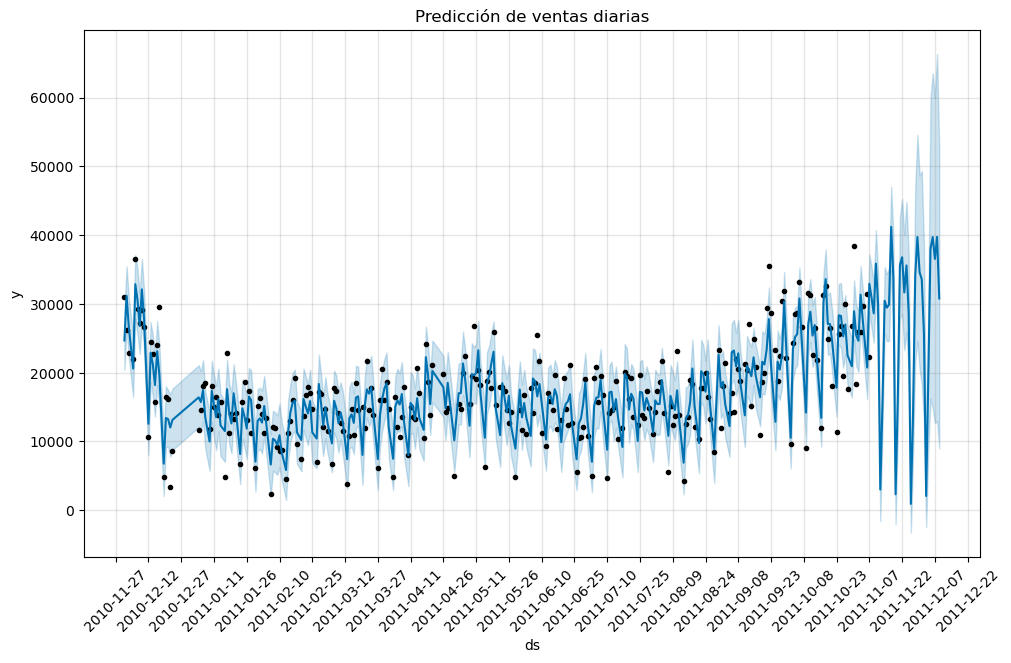

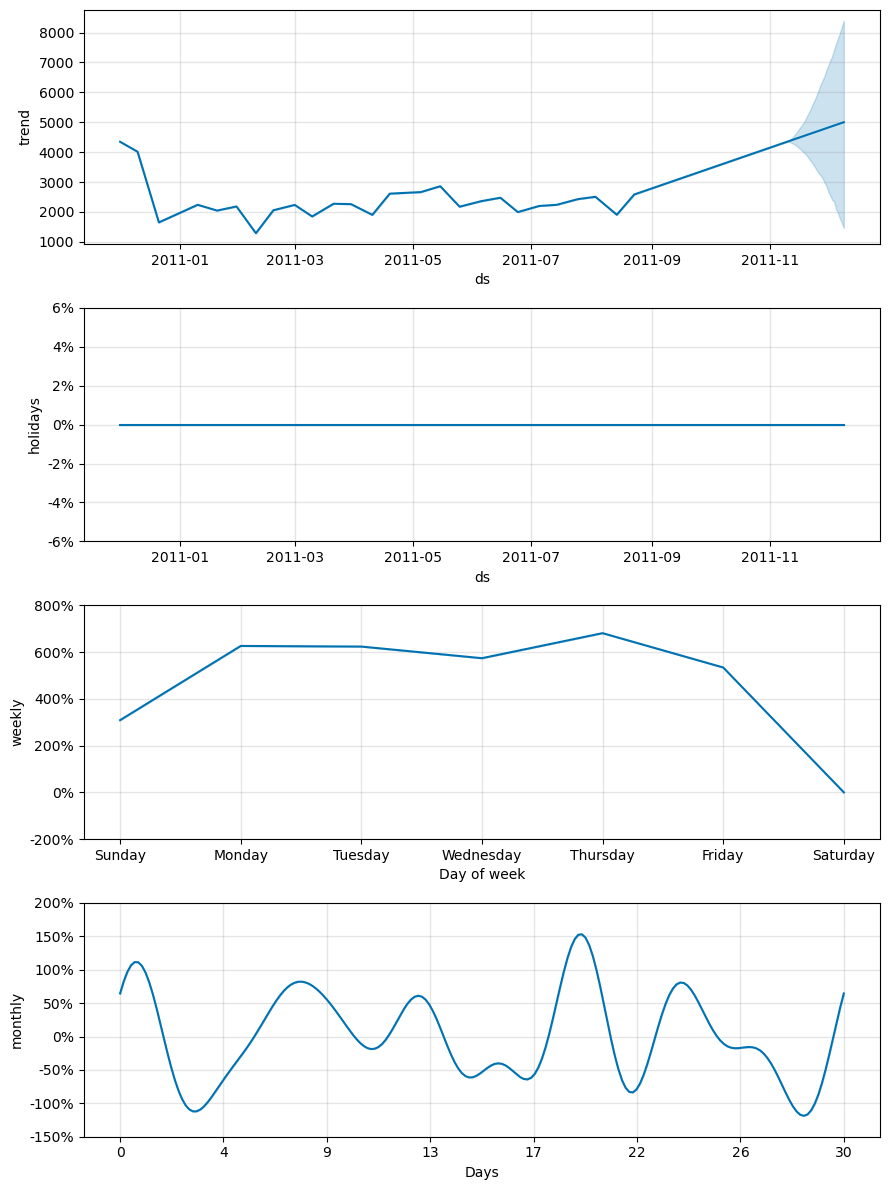

In [280]:
# Gráfico de predicción
fig = model.plot(forecast)
plt.xticks(rotation=45)  
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(31)) 

plt.title('Predicción de ventas diarias')
plt.show()


# Componentes del modelo
fig2 = model.plot_components(forecast)
plt.show()

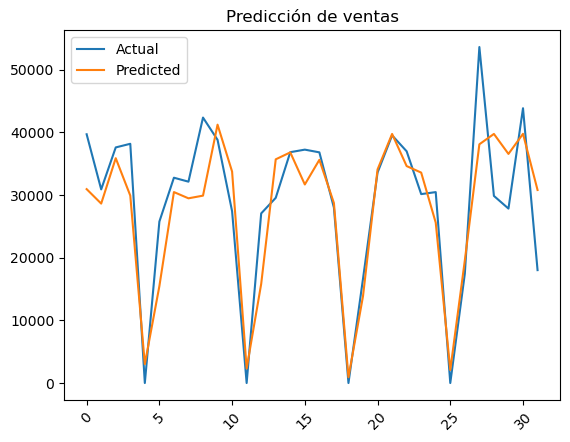

In [250]:
# plot expected vs actual
plt.plot(yRealValues, label='Actual')
plt.plot(yPredValues, label='Predicted')
plt.legend()
plt.xticks(rotation=45)  
plt.title('Predicción de ventas')
plt.show()

In [252]:
# cross validation 
df_cv = cross_validation(model, initial = '300 days', period = '30 days', horizon = '30 days')

  0%|          | 0/1 [00:00<?, ?it/s]

17:43:21 - cmdstanpy - INFO - Chain [1] start processing
17:43:21 - cmdstanpy - INFO - Chain [1] done processing


In [254]:
df_cv.head()

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2011-10-09,14502.173202,10100.532359,18627.706710,9002.00,2011-10-08
1,2011-10-10,26038.371770,21808.956949,30110.978216,31638.18,2011-10-08
2,2011-10-11,29376.018853,25124.442193,33840.562544,31293.43,2011-10-08
3,2011-10-12,26966.709744,22647.779461,31143.508761,22517.38,2011-10-08
4,2011-10-13,29119.052774,24276.147109,33740.593186,26463.58,2011-10-08


C:\Users\adri_\anaconda3\Lib\site-packages\prophet\plot.py:546: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
C:\Users\adri_\anaconda3\Lib\site-packages\prophet\plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
C:\Users\adri_\anaconda3\Lib\site-packages\prophet\plot.py:546: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
C:\Users\adri_\anaconda3\Lib\site-packages\prophet\plot.py:547: FutureWarning: Series.view is deprecated and w

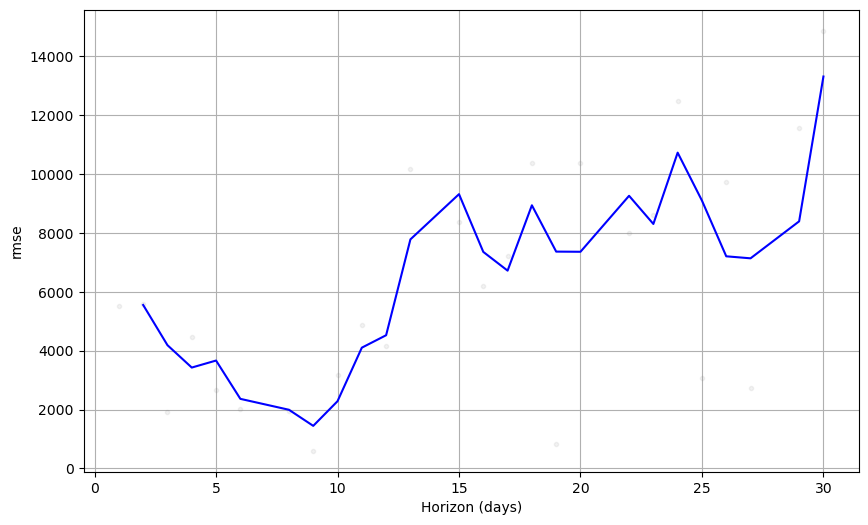

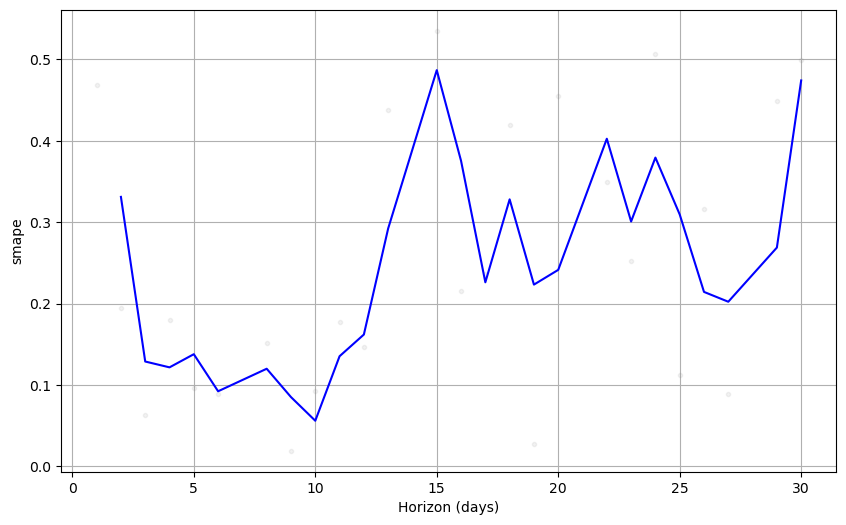

In [256]:
fig = plot_cross_validation_metric(df_cv, metric='rmse')
fig = plot_cross_validation_metric(df_cv, metric='smape')

In [258]:
# performance
df_performance = performance_metrics(df_cv)
print(df_performance)

   horizon           mse          rmse           mae      mape     mdape  \
0   2 days  3.080488e+07   5550.214296   5549.990716  0.393995  0.393995   
1   3 days  1.751716e+07   4185.350506   3758.609688  0.119134  0.119134   
2   4 days  1.173650e+07   3425.857607   3183.370446  0.129434  0.129434   
3   5 days  1.342404e+07   3663.882560   3552.401259  0.148970  0.148970   
4   6 days  5.586026e+06   2363.477618   2342.689249  0.096583  0.096583   
5   8 days  3.971746e+06   1992.924021   1992.574345  0.128030  0.128030   
6   9 days  2.093178e+06   1446.782010   1279.027070  0.091228  0.091228   
7  10 days  5.217640e+06   2284.215322   1888.218270  0.058240  0.058240   
8  11 days  1.681759e+07   4100.924986   4013.913501  0.146119  0.146119   
9  12 days  2.046155e+07   4523.444957   4510.357585  0.176290  0.176290   
10 13 days  6.047921e+07   7776.838195   7172.426385  0.359532  0.359532   
11 15 days  8.670944e+07   9311.790397   9267.096472  0.646238  0.646238   
12 16 days  

In [18]:
def objective(trial):
    sundays = pd.date_range(start=dfPreparacion['ds'].min(), end=dfPreparacion['ds'].max(), freq='W-SAT')
    holidays = pd.DataFrame({'ds': sundays, 'holiday': 'No data'})
    params = {
        'changepoint_prior_scale': trial.suggest_float('changepoint_prior_scale', 3.24, 3.26),
        'changepoint_range': trial.suggest_float('changepoint_range', 0.7, 0.9),
        'seasonality_prior_scale': trial.suggest_float('seasonality_prior_scale', 0.1, 4),
        'holidays_prior_scale': trial.suggest_float('holidays_prior_scale', 0.1, 4),
        'seasonality_mode': trial.suggest_categorical('seasonality_mode', ['multiplicative']),
        'growth': trial.suggest_categorical('growth', ['linear']),
        'weekly_seasonality': trial.suggest_int('weekly_seasonality',7),
        'yearly_seasonality': trial.suggest_int('yearly_seasonality', 0.5, 3),
        'holidays': holidays
    }
   
    model = Prophet(**params)
    model.add_seasonality(name="monthly", period=30.5, fourier_order=10)
    model.add_seasonality(name='weekly', period=7, fourier_order=10)  # Ciclo semanal
    model.fit(dfPreparacion)
    
    future = model.make_future_dataframe(periods=32)
    forecast = model.predict(future)
    
    y_true = dfPreparacion['y'].iloc[-32:].values
    y_pred = forecast['yhat'].iloc[-32:].values
    
    return mean_absolute_error(y_true, y_pred)


In [64]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=2000)

[I 2025-03-20 16:37:52,098] A new study created in memory with name: no-name-8cbb4e1c-4575-423a-8eee-2e3c5a219ce3
16:37:52 - cmdstanpy - INFO - Chain [1] start processing
16:37:52 - cmdstanpy - INFO - Chain [1] done processing
[I 2025-03-20 16:37:52,333] Trial 0 finished with value: 6788.411337932595 and parameters: {'changepoint_prior_scale': 3.2544783433502076, 'changepoint_range': 0.8169477240280927, 'seasonality_prior_scale': 2.168953763981991, 'holidays_prior_scale': 1.3440192344630362, 'seasonality_mode': 'additive', 'growth': 'linear', 'weekly_seasonality': 8, 'yearly_seasonality': 2}. Best is trial 0 with value: 6788.411337932595.
16:37:52 - cmdstanpy - INFO - Chain [1] start processing
16:37:52 - cmdstanpy - INFO - Chain [1] done processing
[I 2025-03-20 16:37:52,557] Trial 1 finished with value: 5966.668604651282 and parameters: {'changepoint_prior_scale': 3.251155617898795, 'changepoint_range': 0.8643847415516286, 'seasonality_prior_scale': 0.9667512068092741, 'holidays_prio

In [66]:
best_params = study.best_params
print("Best hyperparameters:", best_params)
# Best hyperparameters: {'changepoint_prior_scale': 3.2536169105451083, 'changepoint_range': 0.7182298362184354, 'seasonality_prior_scale': 0.3316864024380421, 'holidays_prior_scale': 1.8687582153910482, 'seasonality_mode': 'additive', 'growth': 'linear', 'weekly_seasonality': 7, 'yearly_seasonality': 1}

Best hyperparameters: {'changepoint_prior_scale': 3.258704155349166, 'changepoint_range': 0.8878810751159447, 'seasonality_prior_scale': 0.10045814250510528, 'holidays_prior_scale': 2.170696761338063, 'seasonality_mode': 'additive', 'growth': 'linear', 'weekly_seasonality': 6, 'yearly_seasonality': 0}


In [32]:
param_grid = {
    'changepoint_prior_scale': [3.0, 3.25, 3.5,5],
    'changepoint_range': [0.75, 0.79, 0.83],
    'seasonality_prior_scale': [3.0, 3.2, 3.5,2],
    'holidays_prior_scale': [0.8, 1.0, 1.2],
    'seasonality_mode': ['multiplicative'],
    'growth': ['linear'],
    'weekly_seasonality': [7],
    'yearly_seasonality': [1,2],
    'holidays': [holidays]
}


In [34]:
# Definir variable para almacenar mejores resultados
best_params = None
best_mae = np.inf

# Generar todas las combinaciones posibles
for params in ParameterGrid(param_grid):
    # Crear modelo con los parámetros actuales
    model = Prophet(
        changepoint_prior_scale=params['changepoint_prior_scale'],
        changepoint_range=params['changepoint_range'],
        seasonality_prior_scale=params['seasonality_prior_scale'],
        holidays_prior_scale=params['holidays_prior_scale'],
        seasonality_mode=params['seasonality_mode'],
        growth=params['growth'],
        weekly_seasonality=params['weekly_seasonality'],
        yearly_seasonality=params['yearly_seasonality'],
        holidays=params['holidays']
    )

    # Agregar festivos y estacionalidades personalizadas si es necesario
    model.add_seasonality(name='monthly', period=30.5, fourier_order=10)
    
    # Ajustar el modelo
    model.fit(dfPreparacion)

    # Crear dataframe de predicciones
    future = model.make_future_dataframe(periods=32, freq='D')
    forecast = model.predict(future)

    # Calcular error (MAE) solo en datos reales
    y_true = dfPreparacion['y'][-32:]  # Valores reales de los últimos 32 días
    y_pred = forecast['yhat'][-32:]  # Predicciones de esos días

    mae = mean_absolute_error(y_true, y_pred)

    # Guardar los mejores parámetros
    if mae < best_mae:
        best_mae = mae
        best_params = params

print(f"Mejores parámetros: {best_params} con MAE: {best_mae:.2f}")

08:40:15 - cmdstanpy - INFO - Chain [1] start processing
08:40:15 - cmdstanpy - INFO - Chain [1] done processing
08:40:15 - cmdstanpy - INFO - Chain [1] start processing
08:40:15 - cmdstanpy - INFO - Chain [1] done processing
08:40:16 - cmdstanpy - INFO - Chain [1] start processing
08:40:16 - cmdstanpy - INFO - Chain [1] done processing
08:40:16 - cmdstanpy - INFO - Chain [1] start processing
08:40:16 - cmdstanpy - INFO - Chain [1] done processing
08:40:16 - cmdstanpy - INFO - Chain [1] start processing
08:40:16 - cmdstanpy - INFO - Chain [1] done processing
08:40:16 - cmdstanpy - INFO - Chain [1] start processing
08:40:16 - cmdstanpy - INFO - Chain [1] done processing
08:40:17 - cmdstanpy - INFO - Chain [1] start processing
08:40:17 - cmdstanpy - INFO - Chain [1] done processing
08:40:17 - cmdstanpy - INFO - Chain [1] start processing
08:40:17 - cmdstanpy - INFO - Chain [1] done processing
08:40:17 - cmdstanpy - INFO - Chain [1] start processing
08:40:17 - cmdstanpy - INFO - Chain [1]

Mejores parámetros: {'changepoint_prior_scale': 5, 'changepoint_range': 0.83, 'growth': 'linear', 'holidays':            ds  holiday
0  2010-12-04  No data
1  2010-12-11  No data
2  2010-12-18  No data
3  2010-12-25  No data
4  2011-01-01  No data
5  2011-01-08  No data
6  2011-01-15  No data
7  2011-01-22  No data
8  2011-01-29  No data
9  2011-02-05  No data
10 2011-02-12  No data
11 2011-02-19  No data
12 2011-02-26  No data
13 2011-03-05  No data
14 2011-03-12  No data
15 2011-03-19  No data
16 2011-03-26  No data
17 2011-04-02  No data
18 2011-04-09  No data
19 2011-04-16  No data
20 2011-04-23  No data
21 2011-04-30  No data
22 2011-05-07  No data
23 2011-05-14  No data
24 2011-05-21  No data
25 2011-05-28  No data
26 2011-06-04  No data
27 2011-06-11  No data
28 2011-06-18  No data
29 2011-06-25  No data
30 2011-07-02  No data
31 2011-07-09  No data
32 2011-07-16  No data
33 2011-07-23  No data
34 2011-07-30  No data
35 2011-08-06  No data
36 2011-08-13  No data
37 2011-08-20  N